In [1]:
import pandas as pd
import seaborn as sns
import sqlite3
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [2]:
connection = sqlite3.connect("data_source.db")
df = pd.read_sql("SELECT * FROM raw_data", connection)

In [3]:
print(df.shape)

(10230, 13)


In [5]:
print(df.isnull().sum())

index                  0
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  418
smoking_status         0
stroke                 0
dtype: int64


In [6]:
print(df.dtypes)

index                  int64
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10230 entries, 0 to 10229
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              10230 non-null  int64  
 1   id                 10230 non-null  int64  
 2   gender             10230 non-null  object 
 3   age                10230 non-null  float64
 4   hypertension       10230 non-null  int64  
 5   heart_disease      10230 non-null  int64  
 6   ever_married       10230 non-null  object 
 7   work_type          10230 non-null  object 
 8   Residence_type     10230 non-null  object 
 9   avg_glucose_level  10230 non-null  float64
 10  bmi                9812 non-null   float64
 11  smoking_status     10230 non-null  object 
 12  stroke             10230 non-null  int64  
dtypes: float64(3), int64(5), object(5)
memory usage: 1.0+ MB


In [8]:
df.columns

Index(['index', 'id', 'gender', 'age', 'hypertension', 'heart_disease',
       'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level',
       'bmi', 'smoking_status', 'stroke'],
      dtype='object')

In [9]:
print(df.describe())

              index            id           age  hypertension  heart_disease  \
count  1.023000e+04  10230.000000  10230.000000  10230.000000   10230.000000   
mean   4.181598e+06  22319.167155     43.275629      0.097849       0.054252   
std    5.385846e+06  24398.954449     23.152152      0.297126       0.226526   
min    0.000000e+00     10.000000      0.080000      0.000000       0.000000   
25%    2.556250e+03    911.000000     24.132500      0.000000       0.000000   
50%    2.727000e+04   9343.000000     44.315000      0.000000       0.000000   
75%    8.334604e+06  41968.000000     62.377500      0.000000       0.000000   
max    1.677051e+07  99753.000000     82.000000      1.000000       1.000000   

       avg_glucose_level          bmi        stroke  
count       10230.000000  9812.000000  10230.000000  
mean          113.704927    28.930320      0.049560  
std            53.127365     7.841895      0.217045  
min            55.120000    10.300000      0.000000  
25%      

In [10]:
df.rename(columns={"id": "mrn"}, inplace=True)

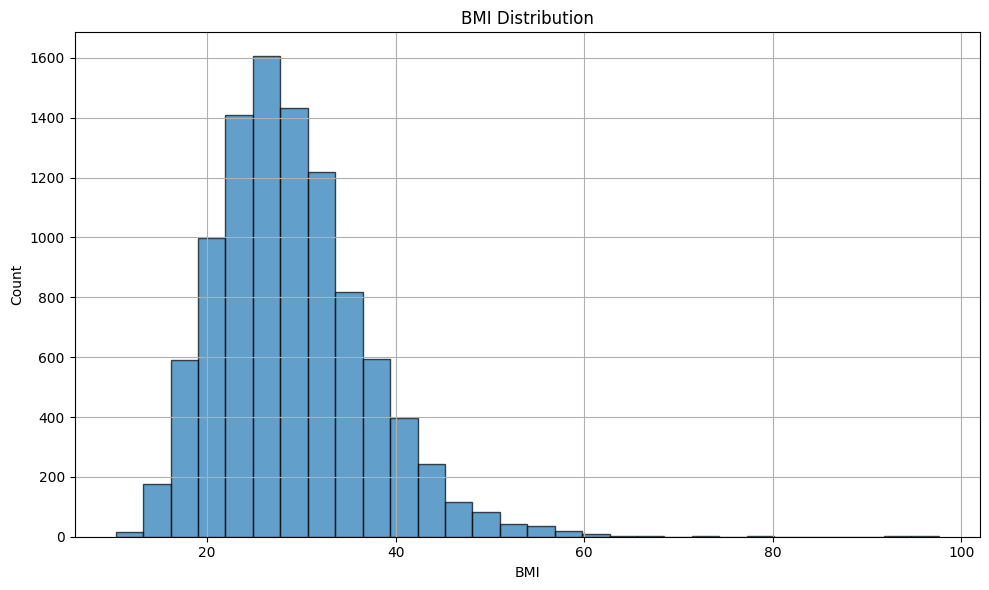

In [11]:
# Plot the distribution
plt.figure(figsize=(10, 6))
plt.hist(df['bmi'], bins=30, edgecolor='black', alpha=0.7)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_1852\1439978410.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10230 entries, 0 to 10229
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              10230 non-null  int64  
 1   mrn                10230 non-null  int64  
 2   gender             10230 non-null  object 
 3   age                10230 non-null  float64
 4   hypertension       10230 non-null  int64  
 5   heart_disease      10230 non-null  int64  
 6   ever_married       10230 non-null  object 
 7   work_type          10230 non-null  object 
 8   Residence_type     10230 non-null  object 
 9   avg_glucose_level  10230 non-null  float64
 10  bmi                10230 non-null  float64
 11  smoking_status     10230 non-null  object 
 12  stroke             10230 non-null  int64  
dtypes: float64(3), int64(5), object(5)
memory usage: 1.0+ MB


In [14]:
df['age_category'] = df['age'].apply(lambda x: 'Pediatric' if x < 16 else 'Adult')

In [15]:
df.columns

Index(['index', 'mrn', 'gender', 'age', 'hypertension', 'heart_disease',
       'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level',
       'bmi', 'smoking_status', 'stroke', 'age_category'],
      dtype='object')

In [16]:
def categorize_glucose(glucose):
    if glucose < 140:
        return "Normal"
    elif 140 <= glucose < 200:
        return "Prediabetic"
    else:
        return "Diabetic"

df['avg_glucose_category'] = df['avg_glucose_level'].apply(categorize_glucose)


In [17]:
df.columns

Index(['index', 'mrn', 'gender', 'age', 'hypertension', 'heart_disease',
       'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level',
       'bmi', 'smoking_status', 'stroke', 'age_category',
       'avg_glucose_category'],
      dtype='object')

In [18]:
df['hypertension'] = df['hypertension'].map({0: "No", 1: "Yes"})

In [19]:
df['heart_disease'] = df['heart_disease'].map({0: "No", 1: "Yes"})

In [20]:
df['stroke'] = df['stroke'].map({0: "No", 1: "Yes"})

In [21]:
df['work_type'] = df['work_type'].map({'Private': "Private", 'Self-employed': "Self-Employed",'Govt_job':"Government-Job"
    , 'children':"Childern"})

In [22]:
df['smoking_status'] = df['smoking_status'].map({'formerly smoked': "Formerly Smoked", 'never smoked': "Never Smoked",'smokes':"Smokes"
    , 'Unknown':"Unknown"})

**Univariant Analysis for Categorical Columns**


In [24]:
categorical_cols = ["gender", "hypertension", "heart_disease", "ever_married", 
                    "work_type", "Residence_type", "smoking_status", "stroke"]

for col in categorical_cols:
    counts = df[col].value_counts()
    fig = go.Figure(data=[go.Bar(x=counts.index, y=counts.values)])
    fig.update_layout(title=f"Distribution of {col}", xaxis_title=col, yaxis_title="Count")
    fig.show()


**Univariant Analysis for Numircal Columns**


In [25]:
numerical_cols = ["age", "avg_glucose_level", "bmi"]

for col in numerical_cols:
    fig = go.Figure(data=[go.Histogram(x=df[col], nbinsx=50)])
    fig.update_layout(title=f"Distribution of {col}", xaxis_title=col, yaxis_title="Count")
    fig.show()

**Bivariate Analysis**


In [26]:
bivariate = ["gender", "hypertension", "heart_disease", "smoking_status", "avg_glucose_category"]

for col in bivariate:
    stroke_yes = df[df["stroke"] == "Yes"][col].value_counts()
    stroke_no = df[df["stroke"] == "No"][col].value_counts()
    
    fig = go.Figure()
    fig.add_trace(go.Bar(name="Stroke: Yes", x=stroke_yes.index, y=stroke_yes.values))
    fig.add_trace(go.Bar(name="Stroke: No", x=stroke_no.index, y=stroke_no.values))
    
    fig.update_layout(barmode='group', title=f"{col} vs Stroke", xaxis_title=col, yaxis_title="Count")
    fig.show()

In [ ]:
conn = sqlite3.connect('enriche_data.db')
df.to_sql('clean_stroke', conn, if_exists='replace', index=False)


10230